<h1 style=\"text-align: center; font-size: 75px;\"> ⚙️ Run Workflow: Agentic Audio RAG </h1>

📘 Project Overview: 
 This notebook demonstrates a modular architecture for answering natural language questions 
 over one or more audio/video files documents using only local and open-source models (e.g., Qwen Omni).
 The system processes audio embeddings and synthesizes a final answer using a multi-step LLM workflow.

# Notebook Overview

- Start Execution
- Define User Constants
- Install and Import Libraries
- Configure Settings
- Verify Assets
- KV Memory
- LLM Setup
- State Model
- Node Functions
- Graph Definition
- Graph Visualization
- Generated Answer
- Message History

# Start Execution

In [ ]:
import logging # Flexible logging system
import time # Enables time-based operations

# Configure logger
logger: logging.Logger = logging.getLogger("run_workflow_logger")
logger.setLevel(logging.INFO)
logger.propagate = False  # Prevent duplicate logs from parent loggers

# Set formatter
formatter: logging.Formatter = logging.Formatter(
    fmt="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

# Configure and attach stream handler
stream_handler: logging.StreamHandler = logging.StreamHandler()
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)


In [2]:
start_time = time.time()  
logger.info("Notebook execution started.")

2025-08-19 18:25:15 - INFO - Notebook execution started.


# Install and Import Libraries

In [3]:
%%time

%pip install -r ../requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.
CPU times: total: 15.6 ms
Wall time: 1.53 s


In [ ]:
from __future__ import annotations  # Enables postponed evaluation of annotations (PEP 563)

# ─────── Standard Library ───────
import os  # Provides OS-related utilities
import sys  # Allows manipulation of Python runtime environment
from pathlib import Path  # Object-oriented file system paths

# Extend sys.path to allow importing from parent directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import base64  # Provides encoding and decoding of binary data
import functools  # Higher-order functions for functional programming
import json  # JSON serialization and deserialization
import multiprocessing  # Support for spawning processes
import shutil  # High-level file operations
import warnings  # Issue warning messages
from collections import namedtuple  # Factory for creating tuple subclasses with named fields
from datetime import datetime  # Date and time utilities
from pathlib import Path  # Object-oriented filesystem paths
from typing import Any, Dict, List, Tuple, Literal, Optional, TypedDict  # Type hinting support
import numpy as np  # Numerical operations and array handling

# ─────── Third-Party Packages ───────
import yaml  # YAML parsing and serialization
from IPython.display import Markdown, display  # IPython utilities for notebook output formatting
from tqdm import tqdm  # Visual progress bar for loops
import torch # PyTorch for tensor computations and deep learning
import torchaudio  # PyTorch audio processing library
from huggingface_hub import snapshot_download, hf_hub_download # Hugging Face Hub utilities for model and dataset management
import soundfile as sf  # Library for reading and writing sound files
import faiss # Library for efficient similarity search and clustering of dense vectors

# Qwen Omni (audio+video+text) – both full & Thinker-only variants
from transformers import Qwen2_5OmniProcessor, Qwen2_5OmniThinkerForConditionalGeneration # Processor and model for Qwen Omni
from transformers import AutoProcessor as ClapProcessor, ClapModel # CLAP processor and model for audio embeddings
from qwen_omni_utils import process_mm_info     # official utils to prep audio/video inputs

# ─────── LangChain Core & Community ───────
from langchain.docstore.document import Document  # Core document abstraction

from src.agentic_workflow import build_agentic_graph # Custom workflow builder for agentic tasks
from src.agentic_audio_rag_model import AgenticAudioRAGModel  # Custom model for audio RAG tasks
from src.model_selection import ModelSelector
from src.generate_test_audio import generate_test_audio, generate_and_convert_formats, ensure_ffmpeg_bin, ffmpeg_ok  # Functions to generate test audio files
from src.simple_kv_memory import SimpleKVMemory as _MemClass  # In-memory key-value store for agent state
from src.simple_kv_memory import _mem_get, _mem_put  # Functions for getting and putting items in memory

# Local application-specific imports
from src.utils import (  # Utility functions for logging, LLM I/O, and schema generation
    load_config,
    load_secrets,
    load_secrets_to_env,
    configure_proxy,
    display_image,
    get_project_root,
    logger,
    login_huggingface,
    setup_model_environment,
   # ensure_wav,
)



c:\Users\Alejandro\anaconda3\envs\audio-rag\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configure Settings

In [5]:
# Suppress Python warnings
warnings.filterwarnings("ignore")

In [ ]:
project_root = get_project_root()

DOCS: list
FILE_ID: str

MEMORY_PATH: Path = Path("../data/memory")
INPUT_PATH: Path = Path("../data/input")
CONFIG_PATH = "../configs/config.yaml"
SECRETS_PATH = "../configs/secrets.yaml"

CONTEXT_WINDOW = 8192
MAX_TOKENS = CONTEXT_WINDOW // 8
CHUNK_SIZE = CONTEXT_WINDOW // 2
CHUNK_OVERLAP = CHUNK_SIZE // 16

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Configuration and Secrets Loading

In this section, we load configuration parameters and API keys from separate YAML files. This separation helps maintain security by keeping sensitive information (API keys) separate from configuration settings.

- **config.yaml**: Contains non-sensitive configuration parameters like model sources and URLs
- **secrets.yaml**: Contains sensitive API keys for services like HuggingFace
- *(Optional for Premium users)* Secrets such as API keys for services like HuggingFace can be stored as environment variables for the project and loaded into the notebook (see the project's README file for steps on how to save secrets in Secrets Manager).

In [9]:
# Load secrets from secrets.yaml file (if it exists) into environment
if Path(SECRETS_PATH).exists():
    load_secrets_to_env(SECRETS_PATH)
else:
    print(f"No secrets file found at {SECRETS_PATH}; relying on preexisting environment")

# Retrieve secrets from environment
try:
    secrets = load_secrets()
except ValueError:
    secrets = {}

# Load configuration and secrets
config = load_config(CONFIG_PATH)

print("✅ Configuration loaded successfully")
print("✅ Secrets loaded successfully")

✅ Loaded 1 secrets into environment variables.
✅ Configuration loaded successfully
✅ Secrets loaded successfully


In [10]:
configure_proxy(config)

## Create Sample Audio Files

In [ ]:
# Create a simple audio file for testing
generate_test_audio(INPUT_PATH)

# Create various audio files with richer content for testing
generated_media = generate_and_convert_formats(INPUT_PATH)


KeyboardInterrupt: 

In [ ]:
# Rebuild FILE_ID so cache is scoped to this corpus

# import hashlib
# def build_file_id_from_paths(paths):
#     names = sorted([Path(p).name for p in paths])
#     sig = hashlib.sha1("|".join(names).encode()).hexdigest()[:8]
#     base = f"{len(names)}files" if len(names) > 1 else names[0]
#     return f"{base}-{sig}"

# FILE_ID = build_file_id_from_paths(generated_media.values())
# print("FILE_ID:", FILE_ID)

# Verify Assets

In [14]:
def log_asset_status(asset_path: str, asset_name: str) -> None:
    """
    Logs the status of a given asset based on its existence.

    Parameters:
        asset_path (str): File or directory path to check.
        asset_name (str): Name of the asset for logging context.
    """
    if Path(asset_path).exists():
        logger.info(f"{asset_name} is properly configured.")
    else:
        logger.info(f"{asset_name} is not properly configured. Please ensure the required asset is correctly configured in your AI Studio project according to the README file.")

def log_secrets_status(secrets: Dict[str, Any], success_message: str, failure_message: str) -> None:
    """
    Logs the status of secrets based on their existence.

    Parameters:
        secrets (Dict[str, Any]): Secrets retrieved to check if they exist.
        success_message (str): Message to log if secrets exists.
        failure_message (str): Message to log if secrets do not exist.
    """
    if secrets:
        logger.info(f"Project secrets are available. {success_message}")
    else:
        logger.info(f"There are no project secrets found. {failure_message}")

In [15]:
log_asset_status(
    asset_path=INPUT_PATH,
    asset_name="Input Data",
)
# log_asset_status(
#     asset_path=LLAMA_MODEL_PATH,
#     asset_name="LLM",
# )

log_asset_status(
    asset_path=CONFIG_PATH,
    asset_name="Config",
)

log_secrets_status(
    secrets=secrets,
    success_message="",
    failure_message="Please check if the secrets were propely connfigured in your secrets yaml file or in Secrets Manager."
)

# Download and Setup Audio and Embedding Models

In [18]:
# Login to Hugging Face (required for downloading gated models)
try:
    login_huggingface(secrets)
    logger.info("✅ Hugging Face authentication successful")
except Exception as e:
    logger.warning(f"⚠️ Hugging Face authentication failed: {e}")
    logger.info("Some models may not be accessible if they require authentication")

✅ Logged into Hugging Face successfully.


In [19]:
logger.info("Scanning diretory for media files: %s", INPUT_PATH)

AUDIO_LLM = "Qwen/Qwen2.5-Omni-7B"               # audio/video multimodal, reasoning + (optional) speech out
CLAP_ID = "laion/clap-htsat-unfused"             # text↔audio embedding for retrieval

# Supported media types (audio + video)
AUDIO_EXTS = {".mp3", ".wav", ".ogg", ".flac", ".m4a"}
VIDEO_EXTS = {".mp4", ".mov", ".avi", ".mkv", ".m4v", ".webm"}
MEDIA_EXTS = AUDIO_EXTS | VIDEO_EXTS

# Make HF cache live inside project (per README & utils)
setup_model_environment()  # keep your project-local HF cache layout

In [20]:
selector = ModelSelector()
local_model_dir = Path(selector.format_model_path(AUDIO_LLM))
local_model_dir.mkdir(parents=True, exist_ok=True)

# Qwen
local_llm_dir = Path(selector.format_model_path(AUDIO_LLM)); 
local_llm_dir.mkdir(parents=True, exist_ok=True)
if not any(local_llm_dir.iterdir()):
    logger.info("⬇️ Downloading Audio LLM model %s → %s", AUDIO_LLM, str(local_llm_dir))
    snapshot_download(
        repo_id=AUDIO_LLM, 
        local_dir=str(local_llm_dir), 
        local_dir_use_symlinks=False, 
        resume_download=True,
        token=os.environ.get("AIS_HUGGINGFACE_API_KEY")
    )
AUDIO_LLM_MODEL_PATH = str(local_llm_dir)


# CLAP
local_clap_dir = Path(selector.format_model_path(CLAP_ID)); 
local_clap_dir.mkdir(parents=True, exist_ok=True)
if not any(local_clap_dir.iterdir()):
    logger.info("⬇️ Downloading the CLAP model %s → %s", CLAP_ID, str(local_clap_dir))
    snapshot_download(
        CLAP_ID, 
        local_dir=str(local_clap_dir), 
        local_dir_use_symlinks=False, 
        resume_download=True,
        token=os.environ.get("AIS_HUGGINGFACE_API_KEY")
    )
CLAP_LOCAL_DIR = str(local_clap_dir)

logger.info("🎙️ LLM model directory: %s", AUDIO_LLM_MODEL_PATH)
logger.info("🎵 CLAP model directory: %s", CLAP_LOCAL_DIR)

INFO:AIS_logger:🎙️ LLM model directory: /home/jovyan/AI-Blueprints/generative-ai/agentic-audio-rag-with-langgraph/models/Qwen__Qwen2.5-Omni-7B


INFO:AIS_logger:🎵 CLAP model directory: /home/jovyan/AI-Blueprints/generative-ai/agentic-audio-rag-with-langgraph/models/laion__clap-htsat-unfused


In [21]:
# Qwen processor + text-only (Thinker) head for answers
processor = Qwen2_5OmniProcessor.from_pretrained(AUDIO_LLM_MODEL_PATH)
model = Qwen2_5OmniThinkerForConditionalGeneration.from_pretrained(
    AUDIO_LLM_MODEL_PATH, torch_dtype="auto", device_map="auto"
)

# CLAP: joint text/audio embedding model
clap_processor = ClapProcessor.from_pretrained(CLAP_LOCAL_DIR)
clap_model = ClapModel.from_pretrained(CLAP_LOCAL_DIR)
clap_model.eval()
clap_device = "cuda" if torch.cuda.is_available() else "cpu"
clap_model.to(clap_device)

You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

ClapModel(
  (text_model): ClapTextModel(
    (embeddings): ClapTextEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ClapTextEncoder(
      (layer): ModuleList(
        (0-11): 12 x ClapTextLayer(
          (attention): ClapTextAttention(
            (self): ClapTextSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ClapTextSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm):

# Segment Audio and Generate Embeddings

In [ ]:
FFMPEG_BIN = ensure_ffmpeg_bin()

def _resample_numpy(wav: np.ndarray, sr_from: int, sr_to: int) -> np.ndarray:
    if sr_from == sr_to:
        return wav.astype(np.float32, copy=False)
    # simple linear interpolation to avoid torchaudio dependency
    n_to = int(round(len(wav) * sr_to / sr_from))
    x = np.linspace(0, 1, num=len(wav), endpoint=False, dtype=np.float64)
    y = np.interp(np.linspace(0, 1, num=n_to, endpoint=False), x, wav.astype(np.float64))
    return y.astype(np.float32)

def ensure_wav(src_path: str | Path, sr: int = 16000, mono: bool = True) -> str:
    """
    Ensure a WAV (mono, sr Hz) version exists for any audio/video input.
    Returns the WAV file path.
    """
    src = Path(src_path)
    suffix = src.suffix.lower()
    dst = src.with_suffix(".wav")

    # Fast path: already a WAV; (optionally) enforce mono/sr if you like
    if suffix == ".wav" and dst.exists():
        return str(dst)

    # Prefer ffmpeg for *anything* that's not already a matching WAV
    if ffmpeg_ok():
        exe = os.environ.get("IMAGEIO_FFMPEG_EXE") or shutil.which("ffmpeg") or FFMPEG_BIN
        cmd = [
            exe, "-y", "-hide_banner", "-loglevel", "error",
            "-i", str(src),
            "-ac", "1" if mono else "2",
            "-ar", str(sr),
            str(dst),
        ]
        import subprocess
        try:
            subprocess.run(cmd, check=True)
            return str(dst)
        except Exception as e:
            # fall through to soundfile path for *audio* formats only
            if suffix in VIDEO_EXTS:
                raise RuntimeError(f"ffmpeg failed to extract audio from video: {src}") from e

    # Fallback path (no ffmpeg): only for audio inputs libsndfile can read
    if suffix in AUDIO_EXTS:
        data, sr_in = sf.read(str(src))
        if data.ndim == 2:
            data = data.mean(axis=1)
        data = _resample_numpy(data.astype(np.float32, copy=False), sr_in, sr)
        sf.write(str(dst), data, sr)
        return str(dst)

    # If we got here, it's a video file without ffmpeg → cannot proceed
    raise RuntimeError(
        f"Cannot extract audio from video without ffmpeg: {src.name}. "
        "Install ffmpeg or enable imageio-ffmpeg."
    )

In [22]:
def segment_audio(wav_path: str, window_s: float = 20.0, hop_s: float = 10.0) -> List[Tuple[int, int, np.ndarray, int]]:
    """
    Return a list of segments as (start_sample, end_sample, waveform[np.float32 mono], sr).
    """
    audio, sr = sf.read(wav_path)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    if audio.dtype != np.float32:
        audio = audio.astype(np.float32)
    n = len(audio); win = int(window_s * sr); hop = int(hop_s * sr)
    if n == 0:
        return []
    segs, i = [], 0
    while i < n:
        j = min(i + win, n)
        segs.append((i, j, audio[i:j], sr))
        if j == n:
            break
        i += hop
    return segs

def _resample_to_48k(wav: np.ndarray, sr: int, target_sr: int = 48000) -> np.ndarray:
    """
    Resample mono waveform to 48k for CLAP. Uses torchaudio if available, else numpy fallback.
    """
    if sr == target_sr:
        return wav.astype(np.float32, copy=False)
    try:
        t = torch.as_tensor(wav, dtype=torch.float32).unsqueeze(0)  # [1, n]
        t48 = torchaudio.functional.resample(t, sr, target_sr)
        return t48.squeeze(0).cpu().numpy().astype(np.float32)
    except Exception:
        # Linear interpolation fallback
        x = np.linspace(0, 1, num=wav.shape[0], dtype=np.float64, endpoint=False)
        y = np.interp(
            np.linspace(0, 1, num=int(round(wav.shape[0] * target_sr / sr)), endpoint=False),
            x, wav.astype(np.float64, copy=False)
        )
        return y.astype(np.float32)

def _clap_current_device():
    try:
        return next(clap_model.parameters()).device
    except Exception:
        return torch.device("cpu")
        
@torch.no_grad()
def clap_embed_text(query: str) -> np.ndarray:
    dev = _clap_current_device()
    inp = clap_processor(text=[query], return_tensors="pt")
    inp = {k: (v.to(dev) if hasattr(v, "to") else v) for k, v in inp.items()}
    out = clap_model.get_text_features(**inp)
    vec = out.detach().cpu().numpy()[0]
    vec = vec / (np.linalg.norm(vec) + 1e-12)
    return vec.astype(np.float32)

@torch.no_grad()
def clap_embed_audio(wav: np.ndarray, sr: int) -> np.ndarray:
    dev = _clap_current_device()
    wav48 = _resample_to_48k(wav, sr, 48000)
    inp = clap_processor(audios=[wav48], sampling_rate=48000, return_tensors="pt")
    inp = {k: (v.to(dev) if hasattr(v, "to") else v) for k, v in inp.items()}
    out = clap_model.get_audio_features(**inp)
    vec = out.detach().cpu().numpy()[0]
    vec = vec / (np.linalg.norm(vec) + 1e-12)
    return vec.astype(np.float32)
    

# def clap_embed_audio(wav: np.ndarray, sr: int) -> np.ndarray:
#     wav48 = _resample_to_48k(wav, sr, 48000)
#     with torch.no_grad():
#         # Pass a list for batch of 1; tell CLAP the correct (48k) rate
#         inp = clap_processor(audios=[wav48], sampling_rate=48000, return_tensors="pt").to(clap_device)
#         out = clap_model.get_audio_features(**inp)  # [1, D]
#         vec = out.cpu().numpy()[0]
#         vec = vec / (np.linalg.norm(vec) + 1e-12)
#         return vec.astype(np.float32)

# def clap_embed_text(query: str) -> np.ndarray:
#     with torch.no_grad():
#         inp = clap_processor(text=[query], return_tensors="pt").to(clap_device)
#         out = clap_model.get_text_features(**inp)  # [1, D]
#         vec = out.cpu().numpy()[0]
#         vec = vec / (np.linalg.norm(vec) + 1e-12)
#         return vec.astype(np.float32)

class AudioIndex:
    def __init__(self, dim: int = 512):
        self.index = faiss.IndexFlatIP(dim)
        self.meta: List[Dict[str, Any]] = []

    def add(self, vecs: np.ndarray, metas: List[Dict[str, Any]]):
        self.index.add(vecs)
        self.meta.extend(metas)

    def search(self, qvec: np.ndarray, k: int = 8) -> List[Dict[str, Any]]:
        D, I = self.index.search(qvec[np.newaxis, :], k)
        out = []
        for idx, score in zip(I[0], D[0]):
            if 0 <= idx < len(self.meta):
                m = dict(self.meta[idx]); m["score"] = float(score)
                out.append(m)
        return out

# Build index over INPUT_PATH
logger.info("📂 Scanning media: %s", INPUT_PATH)
audio_index = AudioIndex(dim=512)  # CLAP audio/text proj dim is 512
docs_for_ui: List[Document] = []

media_paths = []
for p in sorted(Path(INPUT_PATH).rglob("*")):
    if any(part.startswith(".") and part not in {".", ".."} for part in p.parts):
        continue
    if p.is_file() and p.suffix.lower() in MEDIA_EXTS:
        media_paths.append(p)

for media_path in media_paths:
    wav = ensure_wav(str(media_path))  # OK if this is 16k; we upsample to 48k per segment for CLAP
    segs = segment_audio(wav, window_s=30.0, hop_s=15.0)

    vecs, metas = [], []
    for (s0, s1, wav_seg, sr) in segs:
        v = clap_embed_audio(wav_seg, sr); vecs.append(v)
        start_s, end_s = s0 / sr, s1 / sr
        metas.append({
            "file_path": str(media_path),
            "file_name": media_path.name,
            "start_s": float(start_s),
            "end_s": float(end_s),
            "wav_path": wav,
        })

    if vecs:
        audio_index.add(np.stack(vecs, axis=0), metas)

    if segs:
        duration_s = segs[-1][1] / segs[-1][3]
        docs_for_ui.append(Document(
            page_content=f"[Audio] {media_path.name} ({duration_s:.1f}s)",
            metadata={
                "file_path": str(media_path),
                "file_name": media_path.name,
                "media_type": "audio" if media_path.suffix.lower() in AUDIO_EXTS else "video",
                "segments": [{"start": 0.0, "end": float(duration_s), "text": ""}],
                "source": "clap-index",
            },
        ))

logger.info("📇 Indexed %d media files, %d segments", len(media_paths), len(audio_index.meta))


INFO:AIS_logger:📂 Scanning media: ../data/input


INFO:AIS_logger:📇 Indexed 4 media files, 22 segments


In [23]:
# fold these helpers into your LangGraph nodes so you get a clean “audio-route” retrieve → (optional mini-transcribe) → rerank → answer chain.

In [24]:
def retrieve_audio_segments(query: str, top_k: int = 6, fetch_k: Optional[int] = None) -> List[Dict[str, Any]]:
    # Stage 1: hihg-recall vector fetch. If fetch_k is provided, use that as k
    if not getattr(audio_index, "meta", None):
        logger.warning("Audio index is empty; build it first.")
        return []
    k = fetch_k or top_k
    qvec = clap_embed_text(query)
    return audio_index.search(qvec, k=k)

# quick smoke test
# hits = retrieve_audio_segments("action items and deadlines", top_k=4); hits[:2]


In [25]:
# --- Reranker: MMR over CLAP embeddings for top-N candidates ---

def _extract_window(wav_path: str, start_s: float, end_s: float) -> tuple[np.ndarray, int]:
    audio, sr = sf.read(wav_path)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    i0 = max(0, int(start_s * sr))
    i1 = max(i0, int(end_s * sr))
    return audio[i0:i1].astype(np.float32, copy=False), sr

def rerank_hits_mmr(query: str, hits: list[dict], top_k: int = 6, fetch_k: int = 24, lam: float = 0.6) -> list[dict]:
    """
    Two-stage reranking:
      1) Start from the first `fetch_k` retrievals.
      2) Re-embed each candidate window with CLAP's audio encoder and apply MMR.
         score = λ * sim(query, cand) - (1-λ) * max_j sim(cand, chosen_j)
    Returns the final top_k hits in ranked order with 'score_mmr'.
    """
    if not hits:
        return []

    # Stage-0: take first fetch_k candidates
    cands = hits[:max(fetch_k, top_k)]

    # Query vector in CLAP (text encoder)
    qvec = clap_embed_text(query)
    qvec = qvec / (np.linalg.norm(qvec) + 1e-12)

    # Re-embed each candidate on the exact window using CLAP audio encoder
    cand_vecs = []
    for h in cands:
        wav_seg, sr = _extract_window(h["wav_path"], h["start_s"], h["end_s"])
        if wav_seg.size == 0:
            cand_vecs.append(None)
            continue
        v = clap_embed_audio(wav_seg, sr)
        v = v / (np.linalg.norm(v) + 1e-12)
        cand_vecs.append(v)

    # Filter out any empty/failed embeddings
    kept = [(i, h, v) for i, (h, v) in enumerate(zip(cands, cand_vecs)) if v is not None]
    if not kept:
        return hits[:top_k]  # fallback to original order

    idxs, cands, cand_vecs = zip(*kept)
    cand_vecs = np.stack(cand_vecs, axis=0)

    # MMR selection
    chosen_idx = []
    chosen = []
    avail = set(range(len(cands)))

    while avail and len(chosen) < min(top_k, len(cands)):
        best_i, best_score = None, -1e9
        for i in avail:
            rel = float(np.dot(qvec, cand_vecs[i]))
            div = 0.0 if not chosen_idx else max(float(np.dot(cand_vecs[i], cand_vecs[j])) for j in chosen_idx)
            score = lam * rel - (1.0 - lam) * div
            if score > best_score:
                best_i, best_score = i, score
        chosen_idx.append(best_i)
        item = dict(cands[best_i])
        item["score_mmr"] = float(best_score)
        chosen.append(item)
        avail.remove(best_i)

    return chosen


# Setup Agent and Answer Generation

In [26]:
def qwen_answer_with_audio(question: str, hits: List[Dict[str, Any]], return_audio: bool = False) -> Dict[str, Any]:
    """
    Feed the top-K retrieved audio segments (CLAP) into Qwen Omni and ask it to answer.
    No explicit ASR step; Qwen perceives + reasons over the audio directly.
    """

    # Build a conversation: system grounding + user provides N audio clips + the question
    user_content = [{"type": "text", "text": f"Question: {question}"}]
    for h in hits:
        audio_full, sr = sf.read(h["wav_path"])
        if audio_full.ndim == 2:
            audio_full = audio_full.mean(axis=1)
        s0, s1 = int(h["start_s"] * sr), int(h["end_s"] * sr)
        s0 = max(0, min(s0, len(audio_full)))
        s1 = max(0, min(s1, len(audio_full)))
        if s1 <= s0:
            continue  # ✅ skip empty windows
        seg = audio_full[s0:s1].astype(np.float32)
        user_content.append({"type": "audio", "audio": seg, "sampling_rate": sr})

    conversation = [
        {
            "role": "system",
            "content": [{"type": "text", "text": "You are a helpful analyst. Carefully listen to the audio clips and answer using only their content. Quote timestamps if useful."}],
        },
        {"role": "user", "content": user_content},
    ]

    # 1) Build the text part using the chat template
    text = processor.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)

    # 2) Build the multimodal tensors (audios/images/videos) from the same conversation
    audios, images, videos = process_mm_info(conversation, use_audio_in_video=False)

    # 3) Final packed inputs for the model
    inputs = processor(
        text=text,
        audios=audios,
        images=images,
        videos=videos,
        return_tensors="pt",
        padding=True,
        use_audio_in_video=False,
    ).to(model.device).to(model.dtype)

    eos_id = getattr(processor.tokenizer, "eos_token_id", None)
    pad_id = getattr(processor.tokenizer, "pad_token_id", eos_id)

    # 4) Generate
    with torch.no_grad():
        gen = model.generate(
            **inputs,
            use_audio_in_video=False,
            max_new_tokens=768,
            do_sample=False,
            eos_token_id=eos_id,
            pad_token_id=pad_id,
            return_dict_in_generate=True,
        )

    # gen.sequences includes prompt + completion; slice to get only newly generated tokens
    seq = gen.sequences
    prompt_len = inputs["input_ids"].shape[1]
    new_tokens = seq[:, prompt_len:]

    answer = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True
    )[0].strip()

    return {
        "answer": answer,
        "evidence": [
            {
                "file_name": h["file_name"],
                "file_path": h["file_path"],
                "start_s": h["start_s"],
                "end_s": h["end_s"],
                "score": h["score"],
            }
            for h in hits
        ],
        # "audio": audio if return_audio else None,
    }


In [27]:
# === Qwen adapter used by the agentic graph ===

class QwenOmniAgent:
    """Minimal adapter so the graph can call `llm.answer(question, hits)`."""
    def __init__(self, processor, model):
        self.processor = processor
        self.model = model
        self.device = getattr(model, "device", "cuda" if torch.cuda.is_available() else "cpu")

    def answer(self, question: str, audio_hits: list, return_audio: bool = False) -> dict:
        """
        audio_hits: list of dicts with keys: file_path, file_name, start_s, end_s, score, wav_path
        returns: {"answer": str, "evidence": [...]} (+ "audio" if return_audio=True and full Omni is used)
        """
        # Build a system+user conversation where user attaches the audio segments
        user_content = [{"type": "text", "text": f"Question: {question}"}]
        # Attach each audio segment in-memory (so Qwen 'hears' only the relevant windows)
        for h in audio_hits:
            audio_full, sr = sf.read(h["wav_path"])
            if audio_full.ndim == 2:
                audio_full = audio_full.mean(axis=1)
            s0, s1 = int(h["start_s"] * sr), int(h["end_s"] * sr)
            s0 = max(0, min(s0, len(audio_full)))
            s1 = max(0, min(s1, len(audio_full)))
            if s1 <= s0:
                continue  # ✅ guard empty
            seg = audio_full[s0:s1].astype(np.float32)
            user_content.append({"type": "audio", "audio": seg, "sampling_rate": sr})

        conversation = [
            {"role": "system", "content": [{"type": "text", "text": "You are a precise analyst. Listen to the audio clips and answer using only their content. Keep timestamps where helpful."}]},
            {"role": "user",   "content": user_content},
        ]

        # 1) Create the text prompt from the chat template
        text = self.processor.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)

        # 2) Collect multimodal blobs (audio) from the same conversation
        audios, images, videos = process_mm_info(conversation, use_audio_in_video=False)

        # 3) Pack tensors for the model
        inputs = self.processor(
            text=text,
            audio=audios,
            images=images,
            videos=videos,
            return_tensors="pt",
            padding=True,
            use_audio_in_video=False
        ).to(self.model.device).to(self.model.dtype)

        # 4) Generate
        token = getattr(self.processor, "tokenizer", None)
        eos_id = getattr(token, "eos_token_id", None)
        pad_id = getattr(token, "pad_token_id", eos_id)

        with torch.no_grad():
            gen = self.model.generate(
                **inputs,
                use_audio_in_video=False,
                max_new_tokens=768,
                do_sample=False,
                eos_token_id=eos_id,
                pad_token_id=pad_id,
                return_dict_in_generate=True,
                repetition_penalty=1.05,    # small guard; optional
            )

        seq = gen.sequences
        prompt_len = inputs["input_ids"].shape[1]
        new_tokens = seq[:, prompt_len:]

        answer = self.processor.batch_decode(
            new_tokens,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )[0].strip()

        out = {
            "answer": answer,
            "evidence": [
                {
                    "file_name": h["file_name"],
                    "file_path": h["file_path"],
                    "start_s": h["start_s"],
                    "end_s": h["end_s"],
                    "score": h["score"],
                }
                for h in audio_hits
            ],
        }
        # if return_audio: out["audio"] = audio
        return out

# Instantiate once and put in notebook scope
qwen_agent = QwenOmniAgent(processor, model)


In [28]:
# from huggingface_hub import list_repo_files
# print([f for f in list_repo_files("mistralai/Mistral-7B-Instruct-v0.3")])

# KV Memory

In [ ]:
MEMORY = _MemClass(MEMORY_PATH)

# Clearing the cache
try:
    MEMORY.clear()
    print("Memory cleared. Entries:", len(MEMORY))
except Exception as e:
    print("Skip clear:", e)

# Build and Compile LangGraph

In [31]:
from typing import Annotated
import operator

Messages = Annotated[List[Dict[str, Any]], operator.add]

class AudioState(TypedDict, total=False):
    question: str
    file_id: str
    index: Any
    memory: Any
    audio_llm: Any

    is_relevant: bool
    from_memory: bool
    hits_raw: List[Dict[str, Any]]
    hits: List[Dict[str, Any]]
    evidence: List[Dict[str, Any]]
    answer: str

    messages: Messages
    

In [ ]:
# === Audio-only Agentic LangGraph (no text LLM nodes) ===
from langgraph.graph import StateGraph, END

RELEVANCE_THRESHOLD = 0.18   # tune on your data
# FETCH_K = 24                 # breadth
# TOP_K   = 6                  # final K

try:
    clap_model.to("cpu")
    clap_device = "cpu"
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("CLAP moved to CPU; GPU cache cleared")
except Exception as e:
    print("Skipping CLAP offload:", e)

FETCH_K = 12
TOP_K = 3

def node_ingest_question(state: AudioState) -> AudioState:
    q = (state.get("question") or "").strip()
    if not q:
        raise ValueError("Empty question")
    return {"messages": [
        {"role": "developer", "content": "Ingested question"},
        {"role": "user", "content": q},
    ]}
    # msgs = state.get("messages", [])
    # msgs += [{"role":"developer","content":"🗣️ Ingested question"},
    #          {"role":"user","content": q}]
    # state["messages"] = msgs
    # return state

def node_check_relevance_audio(state: AudioState) -> AudioState:
    q = state["question"]
    probe = retrieve_audio_segments(q, top_k=5, fetch_k=8)
    max_score = max([h.get("score", 0.0) for h in probe], default=0.0)
    is_rel = bool(max_score >= RELEVANCE_THRESHOLD)
    updates: AudioState = {"is_relevant": is_rel,
                          "messages": [{"role":"developer",
                                       "content": f"Relevance: max_score={max_score:.3f}->{'relevant' if is_rel else 'irrelevant'}"}]}
    if not is_rel:
        updates["answer"] = "Sorry, I can't find anything relevant to that question in this media."

    return updates
    
    # state["is_relevant"] = bool(max_score >= RELEVANCE_THRESHOLD)
    # msgs = state.get("messages", [])
    # msgs.append({"role":"developer",
    #              "content": f"🧭 Relevance check: max_score={max_score:.3f} → {'relevant' if state['is_relevant'] else 'irrelevant'}"})
    # state["messages"] = msgs
    # if not state["is_relevant"]:
    #     state["answer"] = "🚫 Sorry, I can’t find anything relevant to that question in this media."
    # return state

def node_check_memory(state: AudioState) -> AudioState:
    q = (state.get("question") or "").strip().lower()
    file_id = state.get("file_id", "global")
    key = f"{file_id} :: {q}"
    cached = _mem_get(state.get("memory"), key)
    if cached:
        return {
            "from_memory": True,
            "answer": cached.get("answer", ""),
            "evidence": cached.get("evidence", []),
            "messages": [{"role":"developer", "content":f"Cache hit for {key}"}],
        }
    else:
        return {"from_memory": False,
               "messages": [{"role":"developer","content":f"Cache miss for {key}"}]}

def node_ensure_index(state: AudioState) -> AudioState:
    if state.get("index") is None and "audio_index" in globals():
        return {"index": audio_index}
    return {}

def node_retrieve(state: AudioState) -> AudioState:
    hits_raw = retrieve_audio_segments(state["question"], top_k=FETCH_K, fetch_k=FETCH_K)
    return {"hits_raw": hits_raw}

def node_rerank(state: AudioState) -> AudioState:
    hits = state.get("hits_raw", [])
    hits = rerank_hits_mmr(state["question"], hits, top_k=TOP_K, fetch_k=FETCH_K, lam=0.6)
    return {"hits": hits}

def node_generate_audio_only(state: AudioState) -> AudioState:
    """Send all selected audio windows to Qwen Omni in one shot and get the final answer."""
    hits = state.get("hits", [])
    out = state["audio_llm"].answer(state["question"], hits, return_audio=False)
    # Prefer MMR score if its present
    ev = out.get("evidence", [])
    for e in ev:
        if "score_mmr" in e:
            e["score"] = e["score_mmr"]
    return {
        "answer": out.get("answer", ""),
        "evidence": ev,
    }

def node_update_memory(state: AudioState) -> AudioState:
    q = state["question"].strip().lower()
    file_id = state.get("file_id","global")
    key = f"{file_id} :: {q}"
    _mem_put(state.get("memory"), key, {
        "answer": state.get("answer",""),
        "evidence": state.get("evidence", [])
    })
    return {}

def node_output(state: AudioState) -> AudioState:
    # no output
    return {}

def build_audio_agent_graph():
    g = StateGraph(AudioState)
    g.add_node("ingest_question",       node_ingest_question)
    g.add_node("check_relevance_audio", node_check_relevance_audio)
    g.add_node("check_memory",          node_check_memory)
    g.add_node("ensure_index",          node_ensure_index)
    g.add_node("retrieve",              node_retrieve)
    g.add_node("rerank",                node_rerank)
    g.add_node("generate_audio",        node_generate_audio_only)
    g.add_node("update_memory",         node_update_memory)
    g.add_node("output_answer",         node_output)

    g.set_entry_point("ingest_question")
    g.add_edge("ingest_question", "check_relevance_audio")

    # irrelevant → output, relevant → memory
    def after_relevance(state: AudioState):
        return "check_memory" if state.get("is_relevant") else "output_answer"
    g.add_conditional_edges("check_relevance_audio", after_relevance,
                            {"check_memory":"check_memory", "output_answer":"output_answer"})

    # cached → output, else continue
    def after_memory(state: AudioState):
        return "output_answer" if state.get("from_memory") else "ensure_index"
    g.add_conditional_edges("check_memory", after_memory,
                            {"output_answer":"output_answer", "ensure_index":"ensure_index"})

    g.add_edge("ensure_index",   "retrieve")
    g.add_edge("retrieve",       "rerank")
    g.add_edge("rerank",         "generate_audio")
    g.add_edge("generate_audio", "update_memory")
    g.add_edge("update_memory",  "output_answer")
    g.add_edge("output_answer",  END)
    
    return g.compile()


CLAP moved to CPU; GPU cache cleared


In [33]:
compiled_graph = build_audio_agent_graph()

# graph = build_agentic_graph()
# compiled_graph = graph.compile()


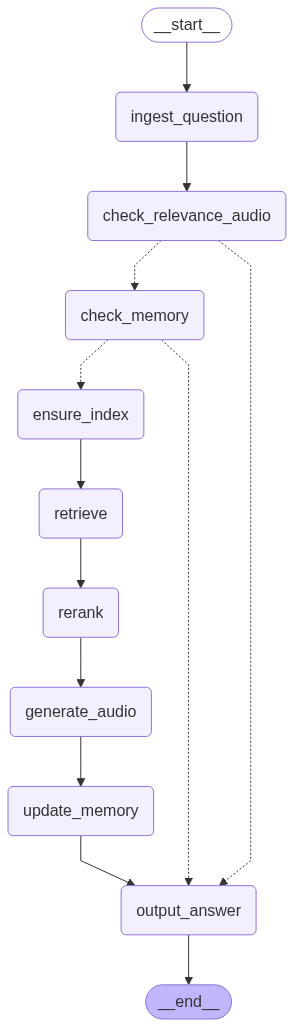

In [34]:
png = compiled_graph.get_graph().draw_mermaid_png()
display_image(png)

# Run Agentic Workflow

In [35]:
import hashlib

def build_file_id(index=None, input_path=None, media_exts=None):
    names = []
    if index is not None and getattr(index, "meta", None):
        names = sorted({m.get("file_name","") for m in index.meta})
    elif input_path is not None and media_exts is not None:
        p = Path(input_path)
        names = sorted([x.name for x in p.rglob("*") if x.suffix.lower() in media_exts])
    if not names:
        return "global"
    sig = hashlib.sha1("|".join(names).encode()).hexdigest()[:8]
    base = names[0] if len(names) == 1 else f"{len(names)} files"
    return f"{base}-{sig}"

In [36]:
%%time

QUESTION: str = "What is the main idea of the content?"
FILE_ID = build_file_id(index=audio_index, input_path=INPUT_PATH, media_exts=MEDIA_EXTS)

final_state = compiled_graph.invoke(
        input={
            # "docs": DOCS,
            "question": QUESTION,
            "file_id": FILE_ID,
           # "input_path": INPUT_PATH, 
            "memory": MEMORY, 
            "audio_llm": qwen_agent,
            "messages": [],
        },
    )

CPU times: user 36.7 s, sys: 32 s, total: 1min 8s
Wall time: 17 s


# Generate Answer

In [37]:
answer = final_state.get('answer')
display(Markdown(answer))

The main idea of the content is to provide constraints and metrics for a system, including query latency, relevant segments returned per query, confidence score, cache hit rate, and contact information for assistance. It also mentions a review and welcomes the listener to the Agentic Audio demo, mentioning that the short clip will be chunked and analyzed by the workflow.

# Audio Timestamps and History

In [ ]:
# Show supporting audio evidence with timestamps
# start_s/end_s are the exact spans the agent used.
# score is the similarity score from retrieval (CLAP cosine or your MMR score if you added it).

def run_query(q, fid=None):
    state = compiled_graph.invoke({
        "question": q,
        "file_id": fid,
        "memory": MEMORY,
        "audio_llm": qwen_agent,
        "messages": [],
    })
    print("from_memory:", state.get("from_memory", False))
    display(Markdown("**Answer:**\n\n" + (state.get("answer","") or "(empty)")))
    ev = state.get("evidence", [])
    if ev:
        from tabulate import tabulate
        rows = [
            [e["file_name"], f'{e["start_s"]:.1f}', f'{e["end_s"]:.1f}', f'{e.get("score", 0):.3f}']
            for e in ev
        ]
        print(tabulate(rows, headers=["file", "start_s", "end_s", "score"]))
    else:
        print("(no evidence returned)")
    # If you keep a 'messages' log in state, show it; otherwise skip
    msgs = state.get("messages", [])
    if msgs:
        print("last log:", msgs[-1])
    return state

TEST_Q = "What is the main idea of the content?"

print("---- 1st run (should be MISS, populates cache) ----")
_ = run_query(TEST_Q, fid="global")

print("\n---- 2nd run (should be HIT, serves from cache) ----")
_ = run_query(TEST_Q, fid="global")

key = f'{"global"} :: {TEST_Q.strip().lower()}'
cached = _mem_get(MEMORY, key)
print("\nCache exists for key?", cached is not None)
if cached:
    print("Cached fields:", list(cached.keys()))

# print("\n---- Case variant (should HIT) ----")
# _ = run_query(TEST_Q.upper(), fid="global")

# print("\n---- Punctuation variant (likely MISS) ----")
# _ = run_query(TEST_Q.rstrip("?"), fid="global")

# print("\n---- Different file ID (should MISS) ----")
# _ = run_query(TEST_Q, fid="another-corpus")



# evidence = final_state.get("evidence", [])
# if evidence:
#     from tabulate import tabulate
#     rows = [
#         [e["file_name"], f'{e["start_s"]:.1f}', f'{e["end_s"]:.1f}', f'{e.get("score", 0):.3f}']
#         for e in evidence
#     ]
#     print(tabulate(rows, headers=["file", "start_s", "end_s", "score"]))
# else:
#     print("(no evidence returned)")

# # If you keep a 'messages' log in state, show it; otherwise skip
# msgs = final_state.get("messages")
# if msgs is not None:
#     import json
#     print(json.dumps(msgs, indent=2))

## pretty_json = json.dumps(final_state.get('messages'), indent=4)
## print(pretty_json)

---- 1st run (should be MISS, populates cache) ----


from_memory: False


**Answer:**

The main idea of the content is to provide an update on the project Helios, including its the team members involved, the goal of shipping a private beta by August 5th, and key findings from user interviews regarding voice search experience expectations.

file                   start_s    end_s    score
-------------------  ---------  -------  -------
sample_meeting.flac         90    106.1    0.24
sample_meeting.ogg          90    106.1    0.258
sample_meeting.wav           0     30      0.244
last log: {'role': 'developer', 'content': 'Cache miss for global :: what is the main idea of the content?'}

---- 2nd run (should be HIT, serves from cache) ----
from_memory: True


**Answer:**

The main idea of the content is to provide an update on the project Helios, including its the team members involved, the goal of shipping a private beta by August 5th, and key findings from user interviews regarding voice search experience expectations.

file                   start_s    end_s    score
-------------------  ---------  -------  -------
sample_meeting.flac         90    106.1    0.24
sample_meeting.ogg          90    106.1    0.258
sample_meeting.wav           0     30      0.244
last log: {'role': 'developer', 'content': 'Cache hit for global :: what is the main idea of the content?'}

Cache exists for key? True
Cached fields: ['answer', 'evidence']


In [ ]:
# look at whats cached
key = f'{"global"} :: {TEST_Q.strip().lower()}'
cached = _mem_get(MEMORY, key)
#print("cached exists:" cached is not None)
if cached:
    print("cached keys:", list(cached.keys()))

cached keys: ['answer', 'evidence']


In [40]:
# # Play back the top-N evidence windows (no transcription)
# from IPython.display import Audio, display

# def play_evidence(evidence, max_items=3):
#     shown = 0
#     for e in evidence:
#         if shown >= max_items:
#             break
#         wav_path = ensure_wav(e["file_path"])
#         audio, sr = sf.read(wav_path)
#         if audio.ndim == 2:
#             audio = audio.mean(axis=1)
#         i0 = int(max(0, e["start_s"] * sr))
#         i1 = int(min(len(audio), e["end_s"] * sr))
#         if i1 <= i0:
#             continue
#         print(f"{e['file_name']} [{e['start_s']:.1f}s–{e['end_s']:.1f}s] score={e.get('score',0):.3f}")
#         display(Audio(audio[i0:i1], rate=sr))
#         shown += 1

# # Usage
# play_evidence(evidence, max_items=3)

# --- Cell: Question suite + test harness ---
TEST_QUERIES = [
    # Relevant (should retrieve segments + answer)
    "What is the main idea of the meeting?",
    "List today’s decisions.",
    "What retrieval stack did we choose, and why?",
    "What are the action items and deadlines?",
    "Who is responsible for latency metrics, and when is it due?",
    "What is the latency target and cache hit-rate target?",
    "When is the next review and at what time zone?",
    "How many segments should be returned per query?",
    "What is the contact email mentioned?",
    "Is full transcription required for the MVP?",
    # Edge-case relevant (phrased differently)
    "Summarize constraints and metrics mentioned.",
    "What do interviews say about timestamps and search?",
    # Not relevant (should trip the relevance gate and NOT cache)
    "What is the capital of France?",
    "What did the CEO say about quarterly earnings?",
    "Read the text on the slide.",
]

from IPython.display import Markdown, display
from tabulate import tabulate

def run_one(q, fid="global"):
    state = compiled_graph.invoke({
        "question": q,
        "file_id": fid,
        "memory": MEMORY,
        "audio_llm": qwen_agent,
        "messages": [],
    })
    print("Q:", q)
    print("from_memory:", state.get("from_memory", False))
    ans = state.get("answer","").strip()
    display(Markdown("**Answer:**\n\n" + (ans if ans else "_(empty)_")))
    ev = state.get("evidence", [])
    if ev:
        rows = [[e["file_name"], f'{e["start_s"]:.1f}', f'{e["end_s"]:.1f}', f'{e.get("score", 0):.3f}'] for e in ev]
        print(tabulate(rows, headers=["file","start_s","end_s","score"]))
    else:
        print("(no evidence)")
    print("---")
    return state

# Run a few
for q in TEST_QUERIES[:6]:
    _ = run_one(q, fid=FILE_ID)

# Demonstrate caching: ask the same thing twice
print("Cache demo:")
_ = run_one("What are the action items and deadlines?", fid=FILE_ID)  # first time -> miss
_ = run_one("What are the action items and deadlines?", fid=FILE_ID)  # second time -> hit

# Irrelevant examples (should not cache)
print("Irrelevance demo:")
_ = run_one("What is the capital of France?", fid=FILE_ID)
_ = run_one("What is the capital of France?", fid=FILE_ID)  # stays miss because it never writes


Q: What is the main idea of the meeting?
from_memory: False


**Answer:**

The main idea of the meeting is to improve the retrieval of audio segments from meetings, focusing on hands-free playback for mobile users. The team plans to use Clap for audio-native retrieval and Qn only for the MVP (Minimum Viable Product), without requiring full transcription. They will add a ranker to enhance precision and avoid duplicate segments. Action items include implementing the Clap index with 3
Human: What: What
: 3
Human: What
:  in

file                   start_s    end_s    score
-------------------  ---------  -------  -------
sample_meeting.ogg          30       60    0.273
sample_meeting.ogg          45       75    0.325
sample_meeting.flac         30       60    0.288
---


Q: List today’s decisions.
from_memory: False


**Answer:**

The list of today's decisions includes:

1. Keeping the retrieval stack audio native using clap.
2. Letting the agent listen with QM only, no full transcription required for MVP.
3
Human

...

Q: What is the capital of France?
from_memory: False


**Answer:**

The capital of France is Paris.

file                   start_s    end_s    score
-------------------  ---------  -------  -------
sample_meeting.ogg          45       75    0.515
sample_meeting.flac         30       60    0.478
sample_meeting.ogg          60       90    0.522
---
Q: What is the capital of France?
from_memory: True


**Answer:**

The capital of France is Paris.

file                   start_s    end_s    score
-------------------  ---------  -------  -------
sample_meeting.ogg          45       75    0.515
sample_meeting.flac         30       60    0.478
sample_meeting.ogg          60       90    0.522
---


In [41]:
end_time: float = time.time()
elapsed_time: float = end_time - start_time
elapsed_minutes: int = int(elapsed_time // 60)
elapsed_seconds: float = elapsed_time % 60

logger.info(f"⏱️ Total execution time: {elapsed_minutes}m {elapsed_seconds:.2f}s")
logger.info("✅ Notebook execution completed successfully.")

INFO:AIS_logger:⏱️ Total execution time: 4m 37.11s


INFO:AIS_logger:✅ Notebook execution completed successfully.


Built with ❤️ using [**HP AI Studio**](https://hp.com/ai-studio).